In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("ggplot") #(for styling)

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


### convert invoice date

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [4]:
snapshot_date = df["InvoiceDate"].max()
print(snapshot_date)

2011-12-09 12:50:00


### RFM analysis

In [5]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Sales": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


### RFM Dataset Overview

In [7]:
rfm.shape
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,342.280000
50%,95.000000,3.000000,867.740000
75%,379.000000,7.000000,2248.305000
max,738.000000,398.000000,580987.040000


### RFM Distribution

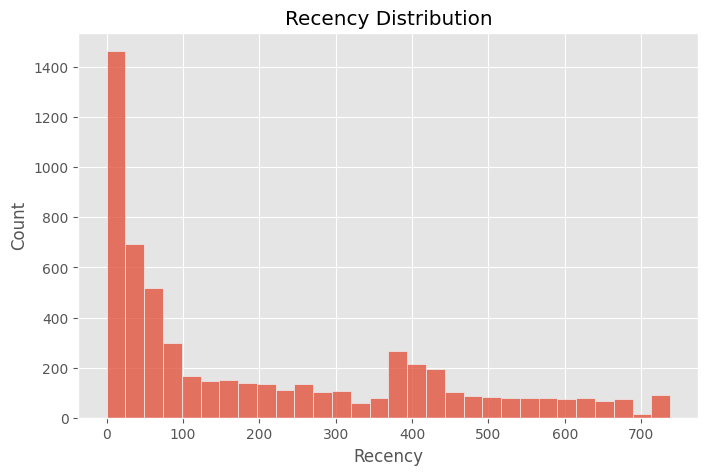

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Recency"], bins=30)
plt.title("Recency Distribution")
plt.show()

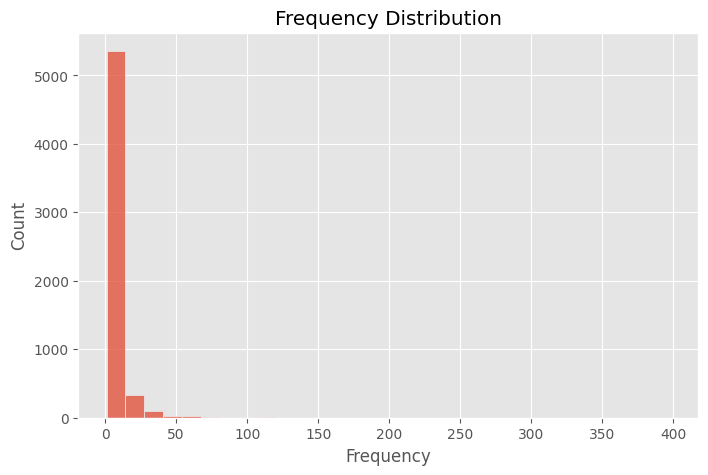

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Frequency"], bins=30)
plt.title("Frequency Distribution")
plt.show()

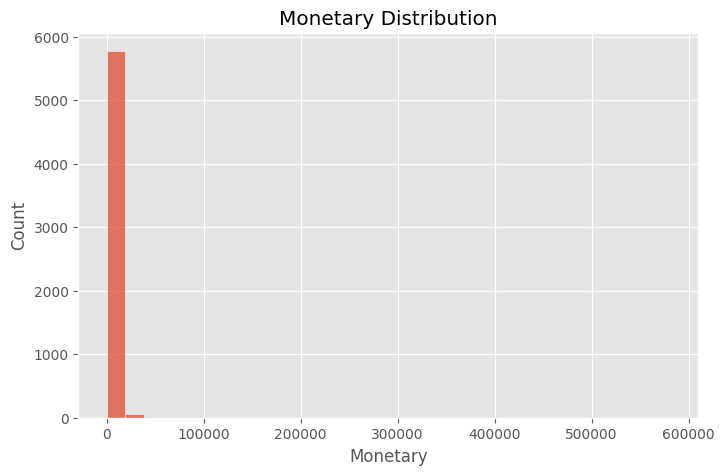

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(rfm["Monetary"], bins=30)
plt.title("Monetary Distribution")
plt.show()

### Feature scaling

In [11]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled[:5]

array([[ 0.59558355,  0.43899789,  5.16637792],
       [-0.95227909,  0.13150188,  0.13612722],
       [-0.60353226, -0.09912012, -0.06485654],
       [-0.87106408, -0.17599412,  0.10199614],
       [ 0.51914589, -0.40661612, -0.18154933]])

### Best K (Elbow Method)

In [12]:
inertia = []
for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

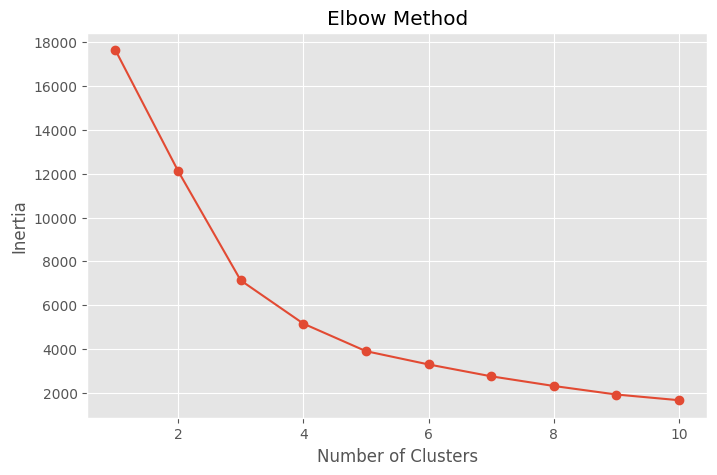

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

###  Apply K-Means Clustering

In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,325,12,77556.46,0
12347.0,1,8,4921.53,0
12348.0,74,5,2019.40,0
12349.0,18,4,4428.69,0
12350.0,309,1,334.40,1


### Cluster Distribution

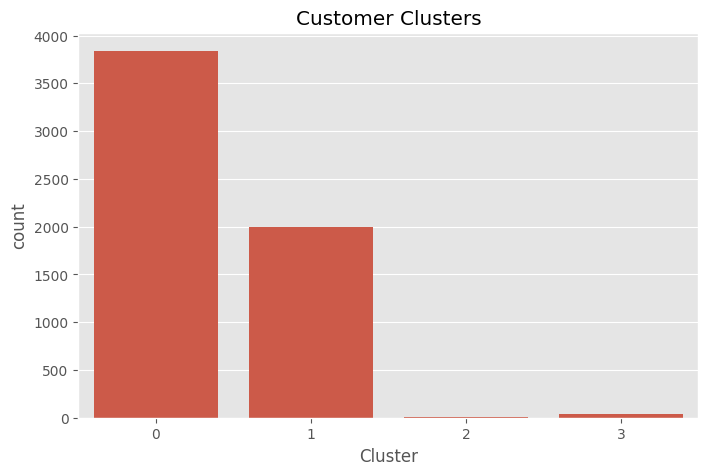

In [15]:
rfm["Cluster"].value_counts()
plt.figure(figsize=(8,5))
sns.countplot(
    x="Cluster",
    data=rfm
)
plt.title("Customer Clusters")
plt.show()

### Cluster Analysis

In [16]:
cluster_summary = rfm.groupby("Cluster").mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,66.054455,7.267848,2921.080058
1,462.032032,2.212212,748.536998
2,2.500000,212.500000,428611.997500
3,23.263158,100.131579,77728.265579


### Customer Segment Labels

In [20]:
rfm["Segment"] = rfm["Cluster"].map({
    0: "Regular Customers",
    1: "At Risk Customers",
    2: "VIP Customers",
    3: "Loyal Customers"
})
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,325,12,77556.46,0,Regular Customers
12347.0,1,8,4921.53,0,Regular Customers
12348.0,74,5,2019.40,0,Regular Customers
12349.0,18,4,4428.69,0,Regular Customers
12350.0,309,1,334.40,1,At Risk Customers


In [18]:
rfm["Segment"].value_counts()

Segment
Regular Customers    3838
VIP Customers        1998
Loyal Customers        38
At Risk Customers       4
Name: count, dtype: int64

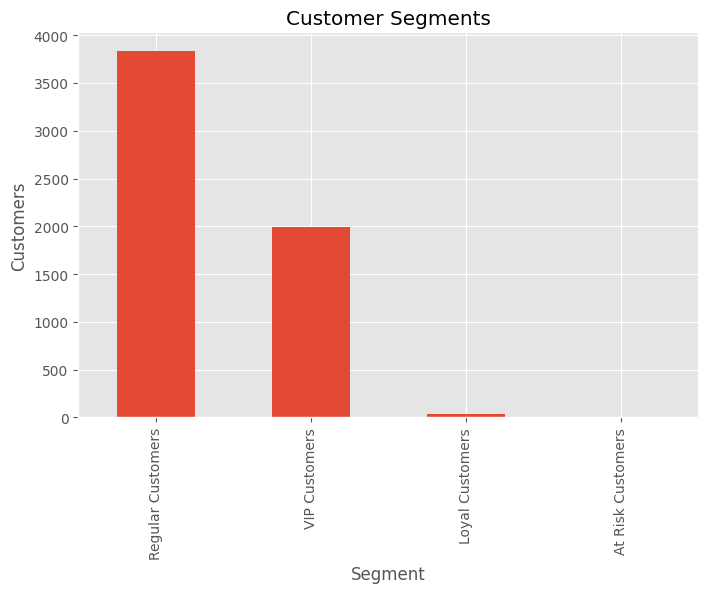

In [19]:
plt.figure(figsize=(8,5))
rfm["Segment"].value_counts().plot(
    kind="bar"
)
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")

plt.show()

### Customer Segment Summary

In [21]:
segment_summary = rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})
segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk Customers,462.032032,2.212212,748.536998
Loyal Customers,23.263158,100.131579,77728.265579
Regular Customers,66.054455,7.267848,2921.080058
VIP Customers,2.500000,212.500000,428611.997500


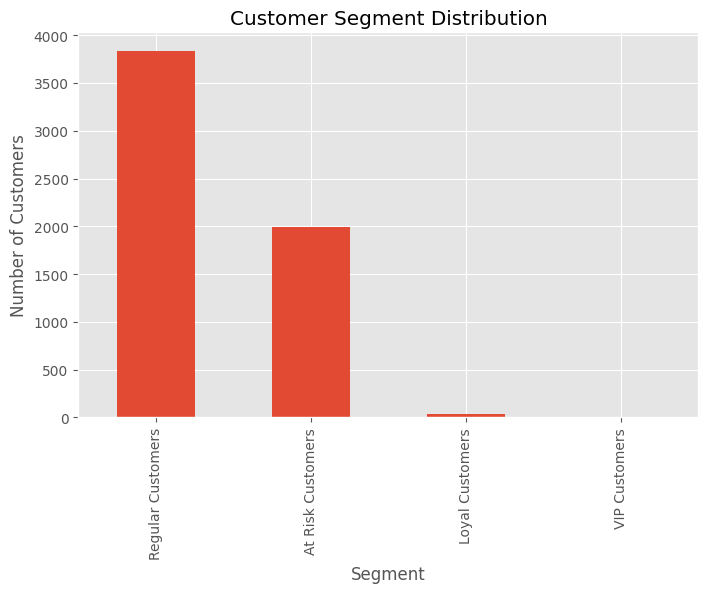

In [22]:
plt.figure(figsize=(8,5))
rfm["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()